# Лабораторная 2.

## Задание 1

1. задаём сферу и направление параллельной проекции в 3D;
2. строим контур тени сферы на плоскости;
3. одной и той же камерой переводим сцену в плоский рисунок;
4. в этой же геометрии выполняем пункты `a`-`e`.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon


def normalize(vector):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm <= 1e-12:
        raise ValueError("Нулевой вектор нельзя нормировать")
    return vector / norm


def orthographic_camera_basis(view_direction, up_hint):
    w = normalize(view_direction)
    u = np.cross(up_hint, w)
    if np.linalg.norm(u) <= 1e-12:
        u = np.cross(np.array([1.0, 0.0, 0.0]), w)
    u = normalize(u)
    v = normalize(np.cross(w, u))
    return u, v


def project_orthographic(points_3d, basis_u, basis_v):
    points_3d = np.asarray(points_3d, dtype=float)
    return np.column_stack((points_3d @ basis_u, points_3d @ basis_v))


def project_to_plane_z0(points_3d, direction):
    points_3d = np.asarray(points_3d, dtype=float)
    direction = normalize(direction)
    if abs(direction[2]) <= 1e-12:
        raise ValueError("Для проекции на z = 0 нужна ненулевая z-компонента направления")
    t = -points_3d[:, 2] / direction[2]
    return points_3d + t[:, None] * direction


def tangent_circle_on_sphere(center, radius, direction, samples=721):
    direction = normalize(direction)
    helper = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(helper, direction)) > 0.9:
        helper = np.array([1.0, 0.0, 0.0])
    basis_1 = normalize(np.cross(direction, helper))
    basis_2 = normalize(np.cross(direction, basis_1))
    angles = np.linspace(0.0, 2.0 * math.pi, samples)
    return np.array(
        [center + radius * (math.cos(t) * basis_1 + math.sin(t) * basis_2) for t in angles],
        dtype=float,
    )


def sample_circle_2d(center, radius, samples=721):
    angles = np.linspace(0.0, 2.0 * math.pi, samples)
    return np.column_stack((center[0] + radius * np.cos(angles), center[1] + radius * np.sin(angles)))


def circle_conic_matrix(center, radius):
    xc, yc = center
    return np.array(
        [
            [1.0, 0.0, -xc],
            [0.0, 1.0, -yc],
            [-xc, -yc, xc * xc + yc * yc - radius * radius],
        ],
        dtype=float,
    )


def affine_transform_matrix(circle_center, circle_radius, ellipse_a, ellipse_b):
    sx = ellipse_a / circle_radius
    sy = ellipse_b / circle_radius
    xc, yc = circle_center
    return np.array(
        [
            [sx, 0.0, -sx * xc],
            [0.0, sy, -sy * yc],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )


def transform_conic(conic, transform):
    inverse = np.linalg.inv(transform)
    return inverse.T @ conic @ inverse


def conic_residual(conic, points):
    homogeneous = np.column_stack((points, np.ones(len(points))))
    return np.einsum("ni,ij,nj->n", homogeneous, conic, homogeneous)


def apply_affine(transform, points):
    homogeneous = np.column_stack((points, np.ones(len(points))))
    mapped = (transform @ homogeneous.T).T
    return mapped[:, :2] / mapped[:, 2:3]


def format_matrix(matrix, digits=6):
    rows = []
    for row in matrix:
        rows.append("[" + ", ".join(f"{value: .{digits}f}" for value in row) + "]")
    return "\n".join(rows)


## 1. Исходные данные и построение 3D-сцены

Если менять `PROJ_DX`, `PROJ_DY`, `PROJ_DZ`, то будет меняться и тень на плоскости, и сам плоский рисунок.

In [2]:
SPHERE_CENTER = np.array([-0.55, 0.00, 1.95], dtype=float)
# R = 0.72
R = 1

PROJECTION_DIRECTION = normalize(np.array([0.45, 0.00, -1.00], dtype=float))
VIEW_DIRECTION = normalize(np.array([0.05, -1.80, 0.65], dtype=float))
UP_HINT = np.array([0.0, 0.0, 1.0], dtype=float)

PLANE_HALF_WIDTH = 2.00
PLANE_HALF_HEIGHT = 0.72
PLANE_SHIFT = np.array([0.10, -0.05, 0.0], dtype=float)
PLANE_ROTATION_DEG = 14.0

basis_u, basis_v = orthographic_camera_basis(VIEW_DIRECTION, UP_HINT)

shadow_center_3d = project_to_plane_z0(SPHERE_CENTER[None, :], PROJECTION_DIRECTION)[0]
tangent_circle_3d = tangent_circle_on_sphere(SPHERE_CENTER, R, PROJECTION_DIRECTION)
shadow_ellipse_3d = project_to_plane_z0(tangent_circle_3d, PROJECTION_DIRECTION)

angle = math.radians(PLANE_ROTATION_DEG)
rotation = np.array(
    [
        [math.cos(angle), -math.sin(angle), 0.0],
        [math.sin(angle), math.cos(angle), 0.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=float,
)
plane_local = np.array(
    [
        [-PLANE_HALF_WIDTH, -PLANE_HALF_HEIGHT, 0.0],
        [ PLANE_HALF_WIDTH, -PLANE_HALF_HEIGHT, 0.0],
        [ PLANE_HALF_WIDTH,  PLANE_HALF_HEIGHT, 0.0],
        [-PLANE_HALF_WIDTH,  PLANE_HALF_HEIGHT, 0.0],
    ],
    dtype=float,
)
plane_patch_3d = plane_local @ rotation.T + shadow_center_3d + PLANE_SHIFT

silhouette_normal = normalize(np.cross(PROJECTION_DIRECTION, VIEW_DIRECTION))
guide_rulings_3d = []
for sign in (-1.0, 1.0):
    base = SPHERE_CENTER + sign * R * silhouette_normal
    line = np.array([base - 1.20 * PROJECTION_DIRECTION, base + 3.20 * PROJECTION_DIRECTION], dtype=float)
    guide_rulings_3d.append(line)

sphere_center_2d = project_orthographic(SPHERE_CENTER[None, :], basis_u, basis_v)[0]
sphere_circle_2d = sample_circle_2d(sphere_center_2d, R)
tangent_circle_2d = project_orthographic(tangent_circle_3d, basis_u, basis_v)
shadow_ellipse_2d = project_orthographic(shadow_ellipse_3d, basis_u, basis_v)
plane_patch_2d = project_orthographic(plane_patch_3d, basis_u, basis_v)
guide_rulings_2d = [project_orthographic(line, basis_u, basis_v) for line in guide_rulings_3d]

print("3D-постановка задана.")
print(f"Центр сферы: {SPHERE_CENTER}")
print(f"Радиус сферы: {R:.6f}")
print(f"Направление параллельной проекции: {PROJECTION_DIRECTION}")


3D-постановка задана.
Центр сферы: [-0.55  0.    1.95]
Радиус сферы: 1.000000
Направление параллельной проекции: [ 0.41036468  0.         -0.91192151]


## 2. Пункт a — ввод системы координат `Oxy`

На плоскости рисунка выбираем систему координат так, чтобы начало было в центре эллипса, а оси совпадали с его главными осями.

In [3]:
ellipse_center_2d = np.mean(shadow_ellipse_2d, axis=0)
centered_ellipse = shadow_ellipse_2d - ellipse_center_2d

covariance = centered_ellipse.T @ centered_ellipse / len(centered_ellipse)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
ellipse_basis = eigenvectors[:, order]
if np.linalg.det(ellipse_basis) < 0.0:
    ellipse_basis[:, 1] *= -1.0

ellipse_a, ellipse_b = np.sqrt(2.0 * eigenvalues)
analytic_ellipse = centered_ellipse @ ellipse_basis
circle_center_in_Oxy = (sphere_center_2d - ellipse_center_2d) @ ellipse_basis

# Выбираем знаки осей так, чтобы картинка была согласована по ориентации.
if circle_center_in_Oxy[0] > 0.0:
    analytic_ellipse[:, 0] *= -1.0
    ellipse_basis[:, 0] *= -1.0
    circle_center_in_Oxy[0] *= -1.0
if circle_center_in_Oxy[1] < 0.0:
    analytic_ellipse[:, 1] *= -1.0
    ellipse_basis[:, 1] *= -1.0
    circle_center_in_Oxy[1] *= -1.0

analytic_circle = sample_circle_2d(circle_center_in_Oxy, R)

print("a) Система координат Oxy")
print("   O = (0, 0) — центр эллипса.")
print("   Ox и Oy направлены вдоль главных осей эллипса.")
print(f"   Центр окружности: C = ({circle_center_in_Oxy[0]:.6f}, {circle_center_in_Oxy[1]:.6f})")
print(f"   Окружность: (x - {circle_center_in_Oxy[0]:.6f})^2 + (y - {circle_center_in_Oxy[1]:.6f})^2 = {R:.6f}^2")
print(f"   Эллипс: x^2 / {ellipse_a ** 2:.6f} + y^2 / {ellipse_b ** 2:.6f} = 1")


a) Система координат Oxy
   O = (0, 0) — центр эллипса.
   Ox и Oy направлены вдоль главных осей эллипса.
   Центр окружности: C = (-0.880314, 1.841383)
   Окружность: (x - -0.880314)^2 + (y - 1.841383)^2 = 1.000000^2
   Эллипс: x^2 / 1.200682 + y^2 / 0.115454 = 1


## 3. Пункты b, c и d

Записываем окружность как конику второго порядка, строим аффинное преобразование `F` и получаем уравнение эллипса-образа.

b) Матрица окружности Q_circle
[ 1.000000,  0.000000,  0.880314]
[ 0.000000,  1.000000, -1.841383]
[ 0.880314, -1.841383,  3.165645]

b.2) Матрица гиперболы Q_hyperbola
[ 0.064000,  0.000000,  0.000000]
[ 0.000000, -0.120000,  0.000000]
[ 0.000000,  0.000000, -1.000000]

c) Матрица аффинного преобразования F
[ 1.095756,  0.000000,  0.964609]
[ 0.000000,  0.339785, -0.625674]
[ 0.000000,  0.000000,  1.000000]

d) Матрица эллипса Q_ellipse = F^{-T} Q_circle F^{-1}
[ 0.832860,  0.000000,  0.000000]
[ 0.000000,  8.661489,  0.000000]
[ 0.000000,  0.000000, -1.000000]
0.832860 x^2 + 0.000000 xy + 8.661489 y^2 + 0.000000 x + 0.000000 y + -1.000000 = 0
После упрощения: x^2 / 1.200682 + y^2 / 0.115454 = 1

d) Матрица "тени" гиперболы Q_hyperbola_shadow = F^{-T} Q_hyperbola F^{-1}
[ 0.832860,  0.000000,  0.000000]
[ 0.000000,  8.661489,  0.000000]
[ 0.000000,  0.000000, -1.000000]
Рисуем окружность и тень (эллипс)


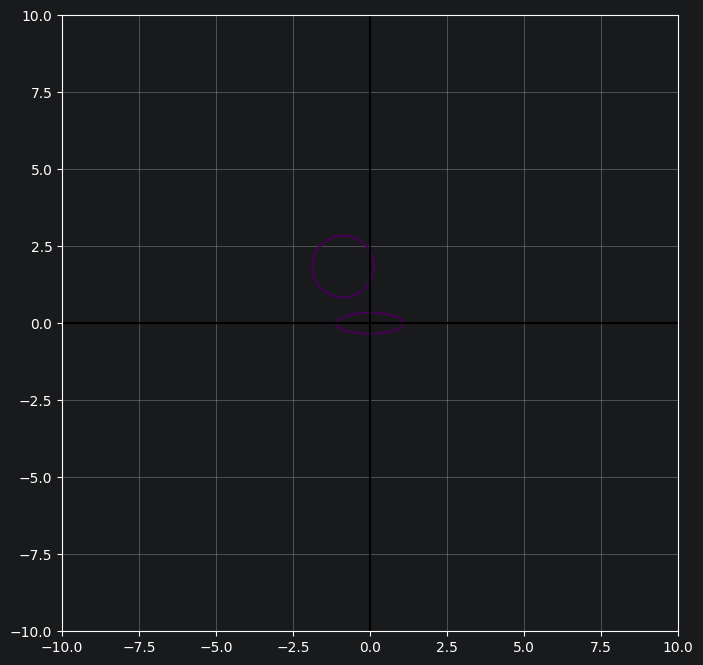

Рисуем гиперболу и тень (гипербола)


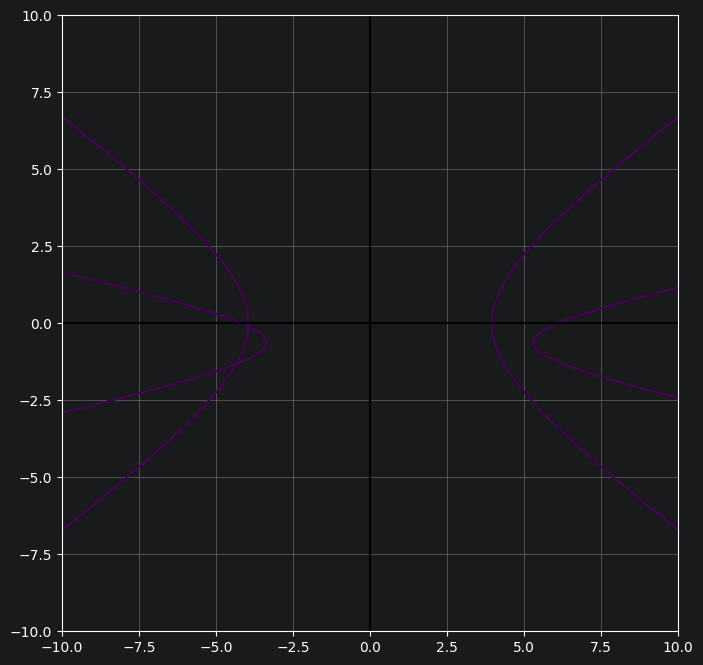

In [12]:
Q_circle = circle_conic_matrix(circle_center_in_Oxy, R)
F = affine_transform_matrix(circle_center_in_Oxy, R, ellipse_a, ellipse_b)
Q_ellipse = transform_conic(Q_circle, F)
Q_ellipse = 0.5 * (Q_ellipse + Q_ellipse.T)

Q_hyperbola = np.array(
    [
        [0.064, 0.0, 0.0],
        [0.0, -0.12, 0.0],
        [0.0, 0.0, -1],
    ],
    dtype=float,
)

Q_hyperbola_shadow = transform_conic(Q_hyperbola, F)
Q_parabola_shadow = transform_conic(Q_parabola, F)

a11 = Q_ellipse[0, 0]
a12 = 2.0 * Q_ellipse[0, 1]
a22 = Q_ellipse[1, 1]
a13 = 2.0 * Q_ellipse[0, 2]
a23 = 2.0 * Q_ellipse[1, 2]
a33 = Q_ellipse[2, 2]

print("b) Матрица окружности Q_circle")
print(format_matrix(Q_circle))
print()
print("b.2) Матрица гиперболы Q_hyperbola")
print(format_matrix(Q_hyperbola))
print()
print("c) Матрица аффинного преобразования F")
print(format_matrix(F))
print()
print("d) Матрица эллипса Q_ellipse = F^{-T} Q_circle F^{-1}")
print(format_matrix(Q_ellipse))
print(
    f"{a11:.6f} x^2 + {a12:.6f} xy + {a22:.6f} y^2 + {a13:.6f} x + {a23:.6f} y + {a33:.6f} = 0"
)
print(f"После упрощения: x^2 / {ellipse_a ** 2:.6f} + y^2 / {ellipse_b ** 2:.6f} = 1")
print()
print("d) Матрица \"тени\" гиперболы Q_hyperbola_shadow = F^{-T} Q_hyperbola F^{-1}")
print(format_matrix(Q_ellipse))

def draw_two_hyperbolas(Q1, Q2):
    x = np.linspace(-10, 10, 1000)
    y = np.linspace(-10, 10, 1000)

    X, Y = np.meshgrid(x, y)

    def conic_value(Q, X, Y):
        return (
            Q[0,0] * X**2 +
            2 * Q[0,1] * X * Y +
            Q[1,1] * Y**2 +
            2 * Q[0,2] * X +
            2 * Q[1,2] * Y +
            Q[2,2]
        )

    Z1 = conic_value(Q1, X, Y)
    Z2 = conic_value(Q2, X, Y)

    plt.figure(figsize=(8, 8))

    plt.contour(X, Y, Z1, levels=[0])

    plt.contour(X, Y, Z2, levels=[0])

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.gca().set_aspect('equal')
    plt.grid()

    plt.show()

print("Рисуем окружность и тень (эллипс)")
draw_two_hyperbolas(Q_circle, Q_ellipse)

print("Рисуем гиперболу и тень (гипербола)")
draw_two_hyperbolas(Q_hyperbola, Q_hyperbola_shadow)



## 4. Пункт e — проверка и рисунок

Ниже показан только плоский рисунок, полученный из той же 3D-сцены. Аналитическая проверка остаётся в численном выводе.

e) Проверка
   Максимальная невязка X^T Q_ellipse X на точках F(circle): 8.882e-16
   Максимальное расстояние между F(circle) и эллипсом из 3D: 1.956e-03


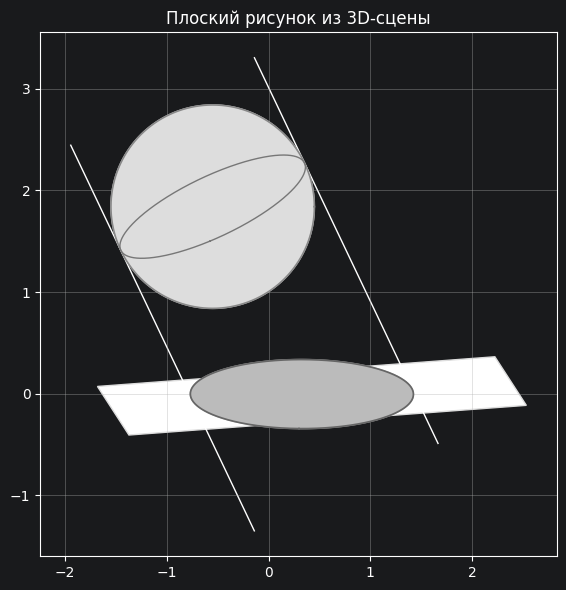

In [5]:
transformed_circle = apply_affine(F, analytic_circle)
max_conic_residual = float(np.max(np.abs(conic_residual(Q_ellipse, transformed_circle))))

pairwise_distances = np.linalg.norm(transformed_circle[:, None, :] - analytic_ellipse[None, :, :], axis=2)
max_curve_distance = float(
    max(
        np.max(np.min(pairwise_distances, axis=1)),
        np.max(np.min(pairwise_distances, axis=0)),
    )
)

print("e) Проверка")
print(f"   Максимальная невязка X^T Q_ellipse X на точках F(circle): {max_conic_residual:.3e}")
print(f"   Максимальное расстояние между F(circle) и эллипсом из 3D: {max_curve_distance:.3e}")

fig, ax_scene = plt.subplots(figsize=(6.8, 6.0))

plane = Polygon(plane_patch_2d, closed=True, facecolor="#fff", edgecolor="#ddd", linewidth=1.0)
ax_scene.add_patch(plane)
for line in guide_rulings_2d:
    ax_scene.plot(line[:, 0], line[:, 1], color="#fff", linewidth=1.0, zorder=1)
ax_scene.fill(sphere_circle_2d[:, 0], sphere_circle_2d[:, 1], color="#ddd", zorder=3)
ax_scene.plot(sphere_circle_2d[:, 0], sphere_circle_2d[:, 1], color="#888", linewidth=1.2, zorder=4)
ax_scene.plot(tangent_circle_2d[:, 0], tangent_circle_2d[:, 1], color="#777", linewidth=1.0, zorder=5)
ax_scene.fill(shadow_ellipse_2d[:, 0], shadow_ellipse_2d[:, 1], color="#bbb", zorder=6)
ax_scene.plot(shadow_ellipse_2d[:, 0], shadow_ellipse_2d[:, 1], color="#666", linewidth=1.25, zorder=7)

scene_arrays = [plane_patch_2d, sphere_circle_2d, tangent_circle_2d, shadow_ellipse_2d] + guide_rulings_2d
xmin = min(np.min(arr[:, 0]) for arr in scene_arrays)
xmax = max(np.max(arr[:, 0]) for arr in scene_arrays)
ymin = min(np.min(arr[:, 1]) for arr in scene_arrays)
ymax = max(np.max(arr[:, 1]) for arr in scene_arrays)
ax_scene.set_xlim(xmin - 0.30, xmax + 0.30)
ax_scene.set_ylim(ymin - 0.25, ymax + 0.25)
ax_scene.set_aspect("equal", adjustable="box")
ax_scene.set_title("Плоский рисунок из 3D-сцены")
# ax_scene.axis("off")
ax_scene.grid()

fig.tight_layout()
plt.show()
